Valeurs Manquantes: nous allons remplacer les "?" par des espaces vides car nos algorithmes de predictions prendrons en compte les valeurs manquantes 

Valeurs Aberrantes: nous allons utiliser la normalisation

Desequilibre des classes: 

correlations: nous allons utiliser la correlation pour determiner les attributs les plus determinants dans le diagnostique



In [3]:
#REMPLACE LES POINT D'INTERROGATION PAR DU VIDE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement
df = pd.read_csv('../data/risk_factors_cervical_cancer.csv')

# Remplacer les '?' par NaN car le dataset utilise '?' pour le vide
df = df.replace('?', np.nan)

# Convertir les colonnes en numérique (important pour l'analyse)
df = df.apply(pd.to_numeric, errors='ignore')

C:\Users\Hp\AppData\Local\Temp\ipykernel_17940\1811695517.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [1]:
#FLOAT64 ET INT32 VERS FLOAT32 ET INT8
import sys
import os
# On remonte d'un cran pour que Python trouve le dossier 'src'
sys.path.append(os.path.abspath('../'))

import pandas as pd
from src.data_processing import optimize_memory

# Appliquer l'optimisation
df = optimize_memory(df)

# Voir le résultat technique
df.info()

: 

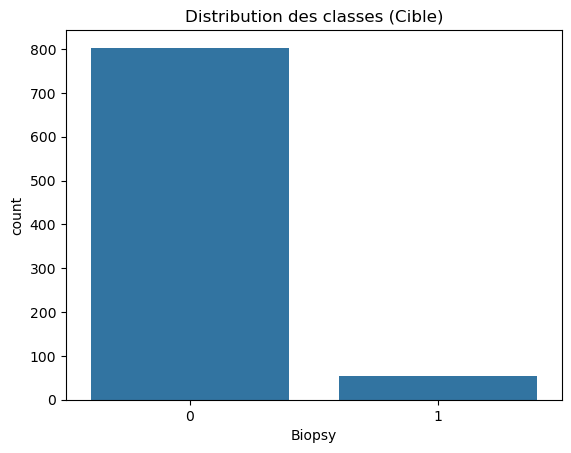

In [ ]:
# POUR VISUALISER LE DESEQUILIBRE 85% 15%
sns.countplot(x='Biopsy', data=df)
plt.title('Distribution des classes (Cible)')
plt.show()

In [1]:

import pandas as pd
import numpy as np

def optimize_memory(df: pd.DataFrame) -> pd.DataFrame:
    """
    Optimise la mémoire du DataFrame en ajustant les types de données (ex: float64 -> float32).
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Mémoire initiale : {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Mémoire finale : {end_mem:.2f} MB')
    return df

c:\Users\ferna\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:55:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Modèle XGBoost entraîné avec succès.
Initialisation de l'explication SHAP (cela peut prendre quelques secondes)...


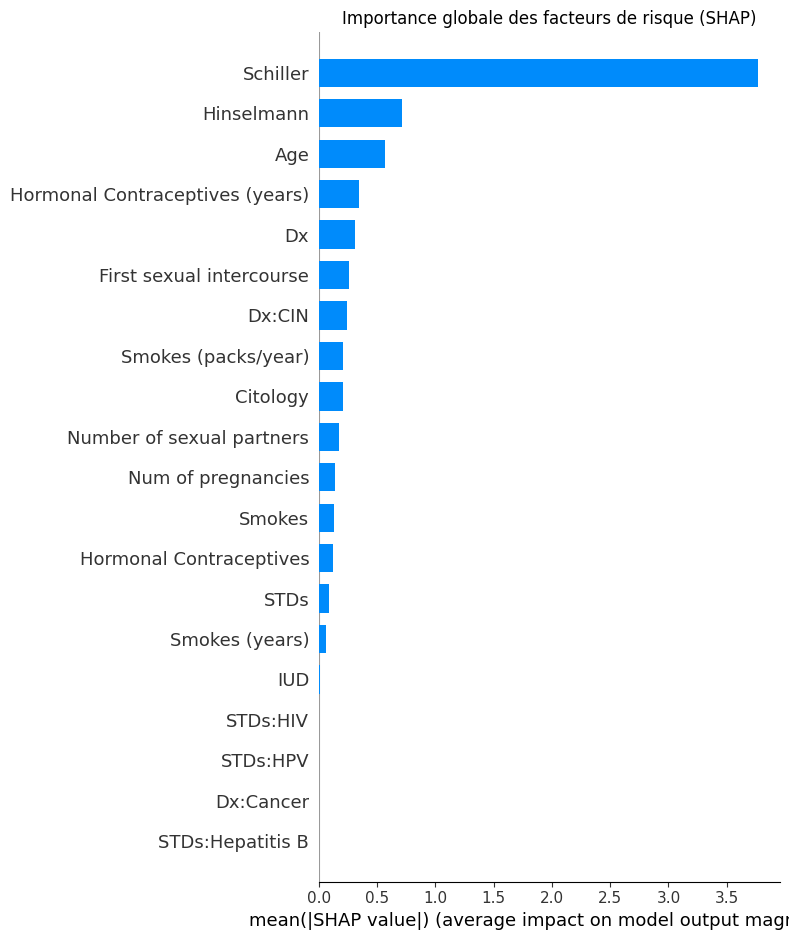

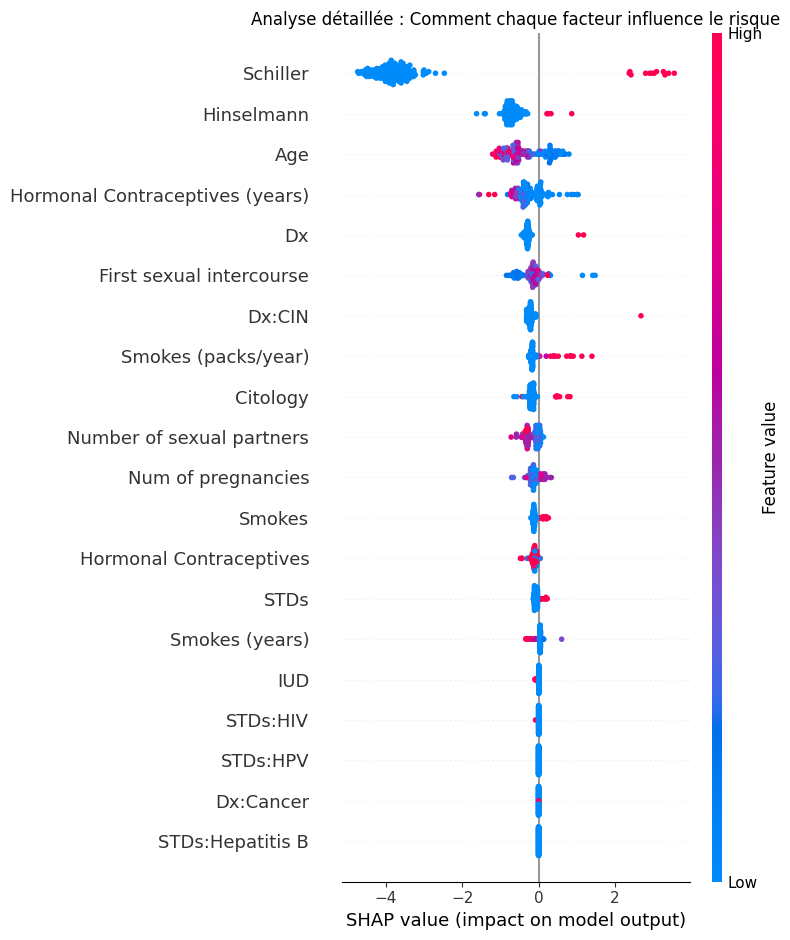

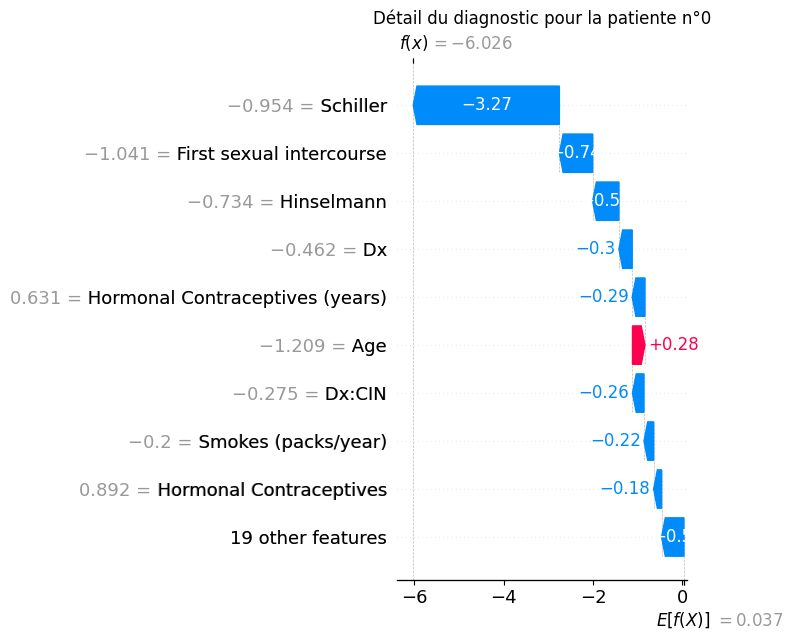

In [2]:
# ============================================================
# Script d'Explicabilité (explainability_SHAP.py)
# ============================================================
import shap
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os

# On ajoute le dossier 'src' au chemin de recherche de Python
sys.path.append(os.path.abspath("../src"))

# On importe le modèle déjà entraîné et les données de test
from train_model_XGBoost import model
from data_processing import X_test_final

print("Initialisation de l'explication SHAP (cela peut prendre quelques secondes)...")

# --- 1. CRÉATION DE L'EXPLAINER ---
# TreeExplainer est optimisé spécifiquement pour les modèles comme XGBoost
explainer = shap.TreeExplainer(model)

# --- 2. CALCUL DES SHAP VALUES ---
# On calcule l'influence de chaque variable pour chaque patiente du jeu de test
shap_values = explainer.shap_values(X_test_final)

# --- 3. VISUALISATION 1 : IMPORTANCE GLOBALE (BARRES) ---
# Ce graphique classe les variables de la plus influente à la moins influente
plt.figure(figsize=(10, 6))
plt.title("Importance globale des facteurs de risque (SHAP)")
shap.summary_plot(shap_values, X_test_final, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# --- 4. VISUALISATION 2 : IMPACT DÉTAILLÉ (BEESWARM) ---
# Ce graphique montre si une valeur forte (rouge) augmente ou diminue le risque
# C'est le graphique le plus riche en informations cliniques
plt.figure(figsize=(12, 8))
plt.title("Analyse détaillée : Comment chaque facteur influence le risque")
shap.summary_plot(shap_values, X_test_final, show=False)
plt.tight_layout()
plt.show()

# --- 5. ZOOM SUR UNE PATIENTE PRÉCISE (Waterfall Plot) ---
# Utile pour l'aide à la décision : explique pourquoi CETTE patiente a ce score
plt.figure(figsize=(10, 6))
# On prend la première patiente du jeu de test (index 0)
patient_index = 0 
shap.plots.waterfall(explainer(X_test_final)[patient_index], show=False)
plt.title(f"Détail du diagnostic pour la patiente n°{patient_index}")
plt.tight_layout()
plt.show()